# Kidney Disease Classification using EfficientNet (Fine-Tune 20 Layers)

In [1]:
# ---------------------------------------------------------
# MOUNT GOOGLE DRIVE
# ---------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ---------------------------------------------------------
# IMPORTS
# ---------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os


In [3]:
# ---------------------------------------------------------
# PATHS UPDATED FOR YOUR DATASET
# ---------------------------------------------------------
base_dir = '/content/drive/MyDrive/Kidney Cancer Split/'

train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

print("Dataset Paths Loaded:")
print("Train :", train_dir)
print("Val   :", val_dir)
print("Test  :", test_dir)


Dataset Paths Loaded:
Train : /content/drive/MyDrive/Kidney Cancer Split/train
Val   : /content/drive/MyDrive/Kidney Cancer Split/val
Test  : /content/drive/MyDrive/Kidney Cancer Split/test


In [4]:
# ---------------------------------------------------------
# DATA GENERATORS
# ---------------------------------------------------------

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=img_size,
    batch_size=batch_size, class_mode='categorical'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size,
    batch_size=batch_size, class_mode='categorical'
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size,
    batch_size=batch_size, class_mode='categorical',
    shuffle=False
)


Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [5]:
# ---------------------------------------------------------
# BUILD EFFICIENTNET MODEL
# ---------------------------------------------------------

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze for phase 1
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')  # 2 classes
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,797 (16.07 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [6]:
# ---------------------------------------------------------
# TRAIN – PHASE 1 (Frozen Base Model)
# ---------------------------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1405s 5s/step - accuracy: 0.5014 - loss: 0.7085 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 128s 510ms/step - accuracy: 0.4980 - loss: 0.7009 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 127s 507ms/step - accuracy: 0.4904 - loss: 0.6972 - val_accuracy: 0.5000 - val_loss: 0.6943
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 128s 512ms/step - accuracy: 0.5043 - loss: 0.6959 - val_accuracy: 0.5000 - val_loss: 0.6932


In [7]:
# ---------------------------------------------------------
# FINE-TUNING – UNFREEZE LAST 20 LAYERS
# ---------------------------------------------------------
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 167s 566ms/step - accuracy: 0.4972 - loss: 0.7091 - val_accuracy: 0.5000 - val_loss: 0.6954
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 131s 523ms/step - accuracy: 0.5098 - loss: 0.7083 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 141s 519ms/step - accuracy: 0.4918 - loss: 0.7032 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 129s 516ms/step - accuracy: 0.4984 - loss: 0.7013 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 129s 515ms/step - accuracy: 0.5018 - loss: 0.7001 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 130s 521ms/step - accuracy: 0.4931 - loss: 0.7002 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 129s 515ms/step - accuracy: 0.4967 - loss: 0.6970 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 129s 517ms/step - accuracy: 0.5102 -

32/32 ━━━━━━━━━━━━━━━━━━━━ 223s 7s/step - accuracy: 0.8276 - loss: 0.6832
Test Accuracy: 52.20%
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 370ms/step
               precision    recall  f1-score   support

kidney_normal       0.51      1.00      0.68       500
 kidney_tumor       1.00      0.04      0.08       500

     accuracy                           0.52      1000
    macro avg       0.76      0.52      0.38      1000
 weighted avg       0.76      0.52      0.38      1000



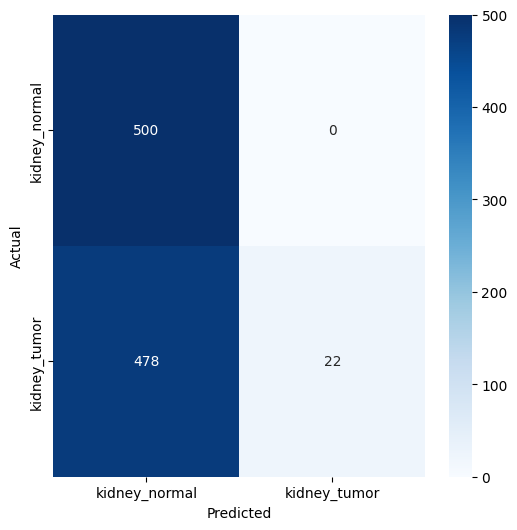

In [8]:
# ---------------------------------------------------------
# EVALUATE MODEL
# ---------------------------------------------------------
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Predictions
y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


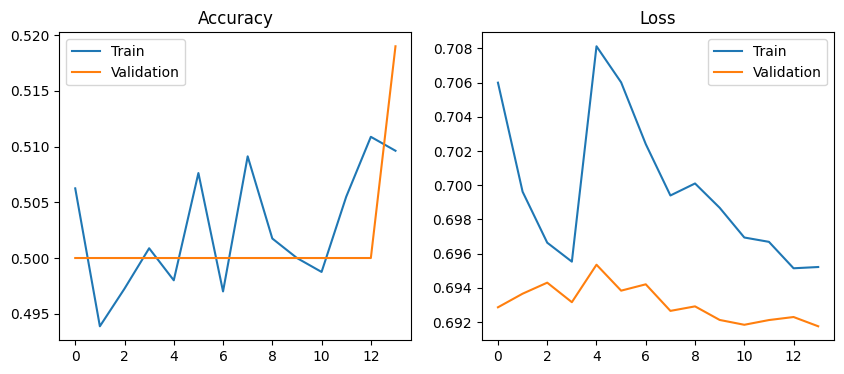

In [9]:
# ---------------------------------------------------------
# PLOT ACCURACY & LOSS
# ---------------------------------------------------------
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'] + fine_tune.history['accuracy'])
plt.plot(history.history['val_accuracy'] + fine_tune.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'] + fine_tune.history['loss'])
plt.plot(history.history['val_loss'] + fine_tune.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])

plt.show()


In [10]:
# ---------------------------------------------------------
# SAVE MODEL
# ---------------------------------------------------------
model.save('/content/kidney_efficientnet.h5')
model.save('/content/drive/MyDrive/kidney_efficientnet.h5')

print("Model saved successfully to Google Drive!")


Model saved successfully to Google Drive!
